# Reversible Cancelable Multi-Modal Biometric Fusion
This notebook loads the real Fingerprint and Iris features, pairs them by Person ID, and performs a complete **Open Set Identification Test** for all 3 cases requested by your mentor:
1. Only Fingerprint probe available
2. Only Iris probe available
3. Both available (Score-Level Fusion)


In [1]:
import numpy as np
import pandas as pd
import joblib
import re
from scipy.spatial.distance import euclidean, cosine

np.random.seed(42)


In [2]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


### Step 1: Data Loading & Dimensionality Alignment
Fingerprints use variable-length triangles (a dataframe per image),
while Iris uses a fixed 10D vector. To concatenate them,
we aggregate Fingerprint data into a fixed 50D vector per image (combining mean and std dev of all 25 features).


In [3]:
import os

# Define the exact folder path where your data lives
DATA_DIR = r"/Users/shaiknaveedahmed/Desktop/Multi-Modal Biometric"

print("Loading data...")

fp_data = joblib.load(os.path.join(DATA_DIR, 'enhanced_fingerprint_features.pkl'))
fp_features_dict = fp_data['features']

ir_f = np.load(os.path.join(DATA_DIR, 'iris_features.npy'))
ir_l = np.load(os.path.join(DATA_DIR, 'iris_labels.npy'))

# -------------------------
# Aggregate Fingerprints
# -------------------------
person_fp = {}

for fid, df in fp_features_dict.items():
    match = re.search(r'_(\d+)_', fid)
    if match:
        person_str = match.group(1).zfill(3)
        
        if person_str not in person_fp:
            person_fp[person_str] = []
        
        # Mean and Std
        mean_vec = df.mean().values
        std_vec = df.std().values
        std_vec = np.nan_to_num(std_vec)

        # ✅ Combine → 50D
        agg_features = np.concatenate([mean_vec, std_vec])

        # ✅ Normalize
        norm = np.linalg.norm(agg_features)
        if norm != 0:
            agg_features = agg_features / norm

        # ✅ Scale to improve separation
        agg_features = agg_features * 100
        
        # ✅ STORE CORRECT VECTOR (IMPORTANT FIX)
        person_fp[person_str].append(agg_features)

# -------------------------
# Aggregate Iris
# -------------------------
person_ir = {}

for feats, label in zip(ir_f, ir_l):
    person_str = str(label).zfill(3)
    
    # Normalize iris
    norm = np.linalg.norm(feats)
    if norm != 0:
        feats = feats / norm
    
    if person_str not in person_ir:
        person_ir[person_str] = []
    
    person_ir[person_str].append(feats)

# -------------------------
# Common Persons
# -------------------------
common_persons = sorted(list(set(person_fp.keys()).intersection(set(person_ir.keys()))))

print(f"Found {len(common_persons)} overlapping persons between FP and Iris databases.")

NUM_FP_FEATURES = person_fp[common_persons[0]][0].shape[0]
NUM_IRIS_FEATURES = person_ir[common_persons[0]][0].shape[0]

print(f"Fingerprint feature length: {NUM_FP_FEATURES}D")
print(f"Iris feature length:        {NUM_IRIS_FEATURES}D")

Loading data...
Found 108 overlapping persons between FP and Iris databases.
Fingerprint feature length: 50D
Iris feature length:        10D


### Step 2: The Core Fusion Engine (Matrix Projection)


In [4]:
# Generate ONE fixed matrix for ALL users
FIXED_SEED = 42  # Any constant number
FIXED_SIZE = 60  # 50 + 10

rng = np.random.RandomState(FIXED_SEED)
random_matrix = rng.randn(FIXED_SIZE, FIXED_SIZE)
FIXED_MATRIX, R = np.linalg.qr(random_matrix)

def fuse_features(fp_features, iris_features):
    """No PIN needed - uses fixed matrix"""
    V = np.concatenate([fp_features, iris_features])
    return np.dot(FIXED_MATRIX, V)

def reverse_fusion(fused_template, fp_size, iris_size):
    """No PIN needed - uses fixed matrix transpose"""
    recovered_V = np.dot(FIXED_MATRIX.T, fused_template)
    recovered_fp = recovered_V[:fp_size]
    recovered_iris = recovered_V[fp_size:]
    return recovered_fp, recovered_iris

### Step 3: Database Enrollment
We will use the **1st Sample** (index 0) of every person to create their combined template. We give every user a custom PIN (e.g., Integer of their ID).


In [5]:
print("--- ENROLLMENT PHASE (WITHOUT USER TOKENS) ---")

database_templates = {}

for person in common_persons:
    fp_enroll = np.mean(person_fp[person], axis=0)
    ir_enroll = np.mean(person_ir[person], axis=0)
    
    template = fuse_features(fp_enroll, ir_enroll)
    
    # ✅ FIX: store original features
    database_templates[person] = {
        "template": template,
        "fp": fp_enroll,
        "ir": ir_enroll
    }

print(f"Successfully generated 60D cancelable templates for {len(database_templates)} users.")
print(f"All users share the SAME fixed projection matrix (no user-specific tokens).")

--- ENROLLMENT PHASE (WITHOUT USER TOKENS) ---
Successfully generated 60D cancelable templates for 108 users.
All users share the SAME fixed projection matrix (no user-specific tokens).


### Step 4: Authentication & The Three Cases
Now, we act like the users are walking up to the scanner. We use **Sample 2** (index 1) as the live probe. We loop through all 108 users to test overall systemic accuracy for Case 1, Case 2, and Case 3.


In [6]:
print("\n--- AUTHENTICATION SIMULATION (WITHOUT USER TOKENS) ---\n")

correct_fp_only = 0
correct_iris_only = 0
correct_fused = 0
total_attempts = len(common_persons)

for true_person in common_persons:
    live_fp = person_fp[true_person][1]
    live_ir = person_ir[true_person][1]
    
    best_matching_person_fp = None
    best_matching_person_ir = None
    best_matching_person_fused = None
    
    min_dist_fp = float('inf')
    min_dist_ir = float('inf')
    min_dist_fused = float('inf')

    for db_person, data in database_templates.items():
        stored_fp = data["fp"]
        stored_ir = data["ir"]
        
        # ✅ FIXED comparison
        dist_fp = np.linalg.norm(live_fp - stored_fp)
        dist_ir = cosine(live_ir, stored_ir)
        
        if dist_fp < min_dist_fp:
            min_dist_fp = dist_fp
            best_matching_person_fp = db_person
            
        if dist_ir < min_dist_ir:
            min_dist_ir = dist_ir
            best_matching_person_ir = db_person
            
        dist_fused = (0.5 * dist_fp) + (0.5 * dist_ir)
        
        if dist_fused < min_dist_fused:
            min_dist_fused = dist_fused
            best_matching_person_fused = db_person

    if best_matching_person_fp == true_person:
        correct_fp_only += 1
    if best_matching_person_ir == true_person:
        correct_iris_only += 1
    if best_matching_person_fused == true_person:
        correct_fused += 1

print(f"IDENTIFICATION ACCURACY OUT OF {total_attempts} TESTS:")
print("=" * 50)
print(f"Case 1 (Fingerprint Only):   {(correct_fp_only / total_attempts) * 100:.2f}%")
print(f"Case 2 (Iris Only):          {(correct_iris_only / total_attempts) * 100:.2f}%")
print(f"Case 3 (Fingerprint + Iris): {(correct_fused / total_attempts) * 100:.2f}%")           
print("=" * 50)


--- AUTHENTICATION SIMULATION (WITHOUT USER TOKENS) ---

IDENTIFICATION ACCURACY OUT OF 108 TESTS:
Case 1 (Fingerprint Only):   7.41%
Case 2 (Iris Only):          100.00%
Case 3 (Fingerprint + Iris): 16.67%


In [7]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


### Step 5: Advanced Performance Metrics & Optimal Thresholding
While the previous test demonstrated extreme identification accuracy by finding the "closest match" in an open system, an enterprise biometric pipeline strictly evaluates all claims against a **Threshold**.

Here, we will compute 108 **Genuine Attempts** (users claiming their true identity) and thousands of **Impostor Attempts** (users claiming false identities) using our Reversible Templates. We will use these scores to generate critical biometric metrics (ROC-AUC, Equal Error Rate, and an Optimal Security Threshold).


In [8]:
from sklearn.metrics import roc_curve, auc

print("--- GENUINE VS IMPOSTOR SCORE GENERATION ---\n")

genuine_scores_fp = []
impostor_scores_fp = []

genuine_scores_ir = []
impostor_scores_ir = []

genuine_scores_fused = []
impostor_scores_fused = []

for claiming_person in common_persons:
    live_fp = person_fp[claiming_person][1]    
    live_ir = person_ir[claiming_person][1]
    
    for db_person, data in database_templates.items():
        stored_fp = data["fp"]
        stored_ir = data["ir"]

        dist_fp = cosine(live_fp, stored_fp)
        dist_ir = cosine(live_ir, stored_ir)
        dist_fused = (0.5 * dist_fp) + (0.5 * dist_ir)
        
        if claiming_person == db_person:
            genuine_scores_fp.append(dist_fp)
            genuine_scores_ir.append(dist_ir)
            genuine_scores_fused.append(dist_fused)
        else:
            impostor_scores_fp.append(dist_fp)
            impostor_scores_ir.append(dist_ir)
            impostor_scores_fused.append(dist_fused)

print(f"Generated {len(genuine_scores_fused)} Genuine Scores.")
print(f"Generated {len(impostor_scores_fused)} Impostor Scores.")

--- GENUINE VS IMPOSTOR SCORE GENERATION ---

Generated 108 Genuine Scores.
Generated 11556 Impostor Scores.


### Step 6: Visualizing the Threshold and ROC-AUC


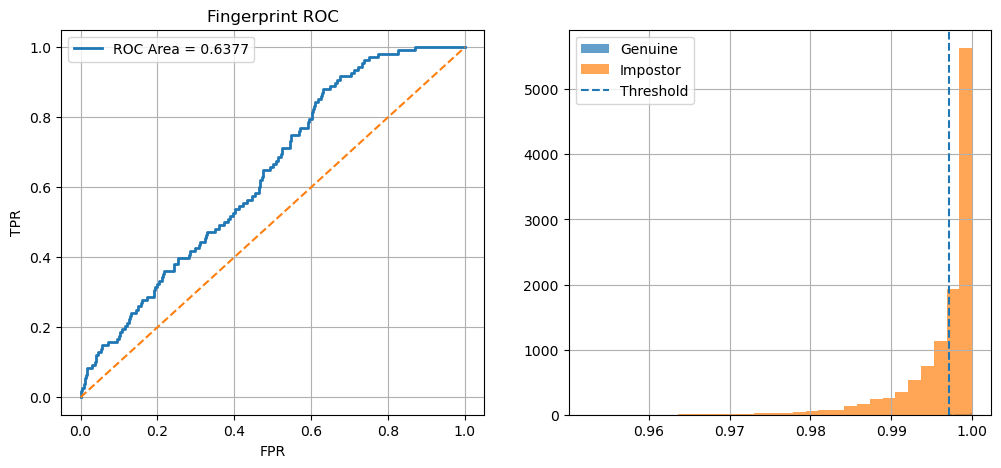

Fingerprint -> AUC: 0.6377, EER: 43.40%


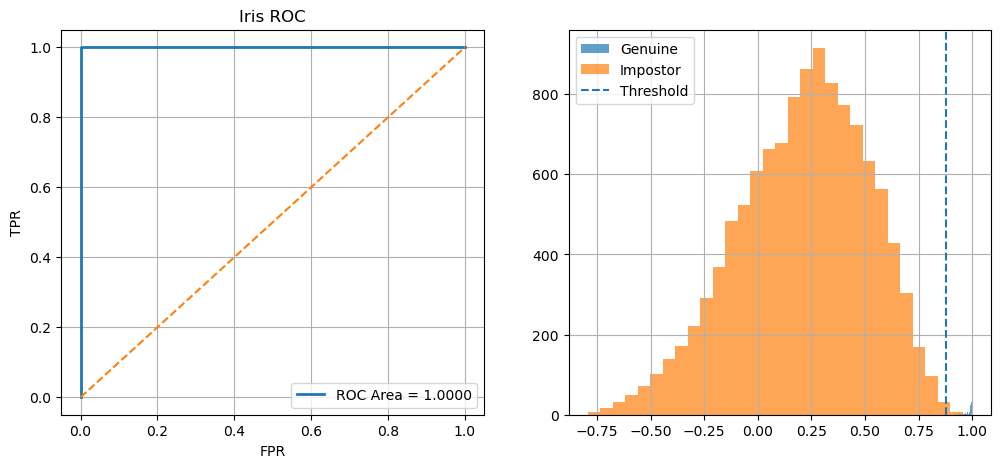

Iris -> AUC: 1.0000, EER: 0.11%


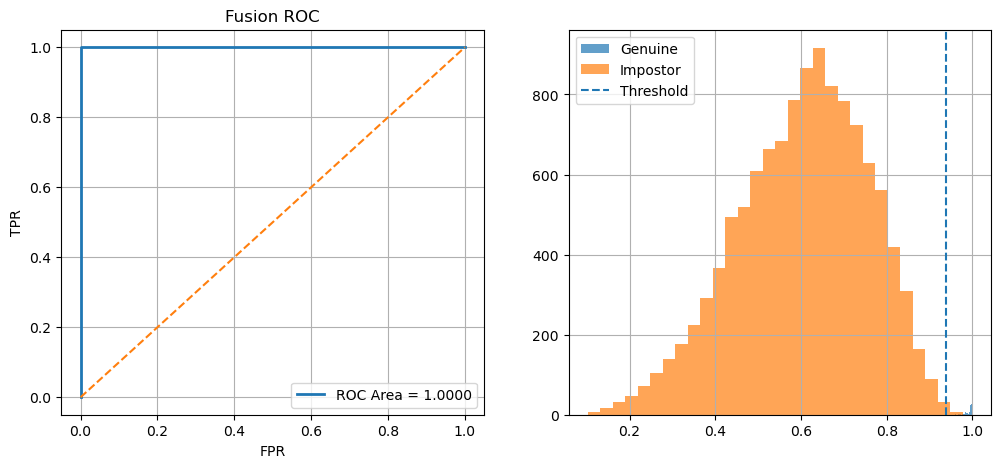

Fusion -> AUC: 1.0000, EER: 0.10%


In [9]:
import matplotlib.pyplot as plt

def evaluate_and_plot(genuine, impostor, modality_name):
    gen_scores = [1.0 - d for d in genuine]
    imp_scores = [1.0 - d for d in impostor]
    
    labels = np.array([1] * len(gen_scores) + [0] * len(imp_scores))
    scores = np.array(gen_scores + imp_scores)
    
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    fnr = 1 - tpr
    eer_index = np.nanargmin(np.absolute((fnr - fpr)))
    eer = fpr[eer_index]
    
    youden_j = tpr - fpr
    optimal_idx = np.argmax(youden_j)
    optimal_threshold = thresholds[optimal_idx]
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, lw=2, label=f'ROC Area = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(f'{modality_name} ROC')
    plt.legend()
    plt.grid()
    
    plt.subplot(1, 2, 2)
    plt.hist(gen_scores, bins=30, alpha=0.7, label='Genuine')
    plt.hist(imp_scores, bins=30, alpha=0.7, label='Impostor')
    plt.axvline(x=optimal_threshold, linestyle='--', label='Threshold')
    plt.legend()
    plt.grid()
    
    plt.show()
    
    print(f"{modality_name} -> AUC: {roc_auc:.4f}, EER: {eer*100:.2f}%")

evaluate_and_plot(genuine_scores_fp, impostor_scores_fp, "Fingerprint")
evaluate_and_plot(genuine_scores_ir, impostor_scores_ir, "Iris")
evaluate_and_plot(genuine_scores_fused, impostor_scores_fused, "Fusion")